## **Supervised Model II – MLP**

## **Trial Phase**

**Load Training Dataframe**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from feature_pipeline import load_data, exclude_test_users, compute_item_stats, build_features, get_feature_columns

# Load raw data and build features via centralised pipeline (leakage-safe)
XX_train, yy_all, XX_test = load_data("data/training_batch_with_labels.npz", "data/subset_training_batch.npz")

# Remove test users from training to prevent leakage 
XX_train, yy = exclude_test_users(XX_train, yy_all, XX_test)

# Freeze item stats from training users only
item_stats = compute_item_stats(XX_train)

# Training features (880 users)
user_df = build_features(XX_train, item_stats).merge(yy, on="user")
feature_cols = get_feature_columns(user_df)
X_features = user_df[feature_cols].values
y_labels = user_df["label"].values

# Test features (220 users, using frozen training item stats — no leakage)
test_df = build_features(XX_test, item_stats)
X_test = test_df[feature_cols].values

# Ground truth labels for the 220 test users (from original full label set)
test_labels = test_df[["user"]].merge(yy_all, on="user")["label"].values

print(f"Train: {X_features.shape[0]} users, {len(feature_cols)} features")
print(f"Test:  {X_test.shape[0]} users (labels available for local evaluation)")

Excluded 220 overlapping users from training (1100 → 880 users)
Train: 880 users, 24 features
Test:  220 users (labels available for local evaluation)


In [3]:
# Random seed for reproducibility
RANDOM_SEED = 42

Expectation: MLP should perform better than the Logistic Regression model as it is more flexible and can learn nonlinear patterns within the data

In [9]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [10]:
# Tunable paramters:
val_split = 0.15
initial_learning_rate = 0.001

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),                  # two hidden layers: 64 neurons then 32
        activation="relu",                            # standard activation function
        max_iter=500,                                 # training epochs
        early_stopping=True,                          # stop if validation score stops improving
        validation_fraction=val_split,                # use val_split% of training data for validation and early stopping
        learning_rate_init=initial_learning_rate,     # starting learning rate
        random_state=RANDOM_SEED
    ))
])

# To handle imblanace, oversample anomalous users with SMOTE
mlp_smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_SEED)),  # creates synthetic anomalous samples
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        validation_fraction=val_split,
        learning_rate_init=initial_learning_rate,
        random_state=RANDOM_SEED
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

mlp_scores = []
mlp_smote_scores = []

for train_idx, val_idx in skf.split(X_features, y_labels):
    X_train, X_val = X_features[train_idx], X_features[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]

    mlp_pipeline.fit(X_train, y_train)
    y_prob = mlp_pipeline.predict_proba(X_val)[:, 1]
    y_pred = mlp_pipeline.predict(X_val)
    mlp_scores.append(roc_auc_score(y_val, y_prob))

    mlp_smote_pipeline.fit(X_train, y_train)
    y_prob_smote = mlp_smote_pipeline.predict_proba(X_val)[:, 1]
    y_pred_smote = mlp_smote_pipeline.predict(X_val)
    mlp_smote_scores.append(roc_auc_score(y_val, y_prob_smote))


print(f"MLP AUC: {np.mean(mlp_scores):.4f} ± {np.std(mlp_scores):.4f}")
print(f"MLP SMOTE AUC: {np.mean(mlp_smote_scores):.4f} ± {np.std(mlp_smote_scores):.4f}")

MLP AUC: 0.8556 ± 0.0356
MLP SMOTE AUC: 0.8901 ± 0.0342


SMOTE generates synthetic anomalous users by interpolating between existing anomalois samples, in an attempt to provide the MLP with a balanced dataset during training.

**Train MLP models (with and without SMOTE)**

In [11]:
# Train MLP and MLP_SMOTE on full data
mlp_pipeline.fit(X_features, y_labels)
mlp_smote_pipeline.fit(X_features, y_labels)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,sampling_strategy,'auto'
,random_state,42
,k_neighbors,5
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"


**Analyse the MLP model (without SMOTE)** ‼️ explain t-SNE

/var/folders/9z/pvdb521n5m3541jlwh8jmgzh0000gn/T/ipykernel_10148/3997025232.py:27: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(*scatter.legend_elements(), labels=["Normal", "Anomalous"])


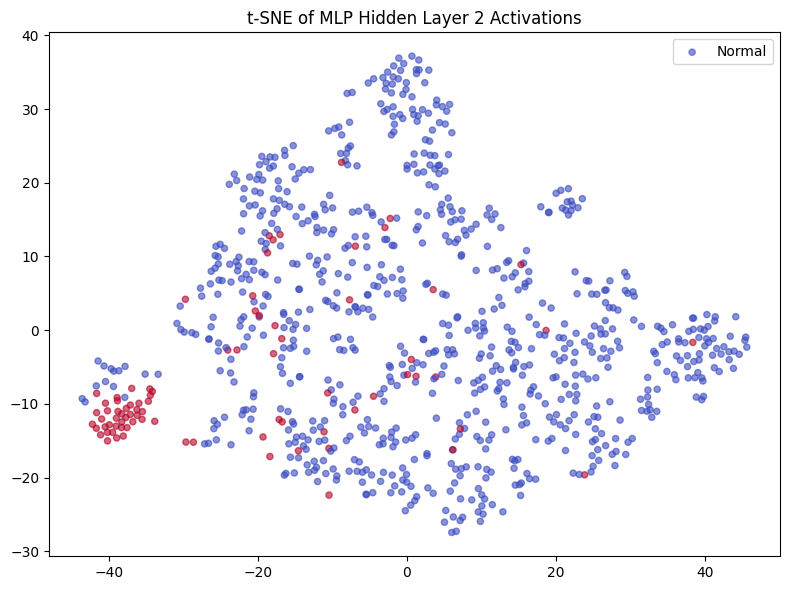

In [12]:
from sklearn.manifold import TSNE

# Extract the scaler and trained MLP
scaler_mlp = mlp_pipeline.named_steps["scaler"]
mlp = mlp_pipeline.named_steps["mlp"]

# Scale the full dataset (not just the last CV fold)
X_scaled = scaler_mlp.transform(X_features)

# Manually pass data through hidden layers to get activations
# Layer 1 output
hidden1 = np.maximum(0, X_scaled @ mlp.coefs_[0] + mlp.intercepts_[0])  # ReLU
# Layer 2 output
hidden2 = np.maximum(0, hidden1 @ mlp.coefs_[1] + mlp.intercepts_[1])   # ReLU

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings = tsne.fit_transform(hidden2)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    embeddings[:, 0], embeddings[:, 1],
    c=y_labels, cmap="coolwarm", alpha=0.6, s=20
)
ax.set_title("t-SNE of MLP Hidden Layer 2 Activations")
ax.legend(*scatter.legend_elements(), labels=["Normal", "Anomalous"])
plt.tight_layout()
plt.show()

The anomalies generally form one cluster on the left, but there are still some anomalous points within the normal cluster. The model is likely to misclassify these anomalous points.

**Test MLP models**

In [21]:
# Predict scores on test data (X_test built from feature_pipeline with frozen item stats)
y_score_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]
y_score_smote = mlp_smote_pipeline.predict_proba(X_test)[:, 1]

# Local evaluation (test users excluded from training — no leakage)
print("MLP (local test set — 220 unseen users):")
print(f"AUC: {roc_auc_score(test_labels, y_score_mlp):.4f}")
print()
print("MLP + SMOTE (local test set — 220 unseen users):")
print(f"AUC: {roc_auc_score(test_labels, y_score_smote):.4f}")

# Save as submission.npz
np.savez('mlp.npz', predictions=y_score_mlp)
np.savez('mlp_smote.npz', predictions=y_score_smote)

MLP (local test set — 220 unseen users):
AUC: 0.8490

MLP + SMOTE (local test set — 220 unseen users):
AUC: 0.8732


**Results from Codabench:**


In [14]:
# MLP:
# AUC:       0.7761
# Precision: 0.0000
# Recall:    0.0000
# F1 Score:  0.0000

In [15]:
# MLP_SMOTE:
# AUC:       0.7272
# Precision: 0.0000
# Recall:    0.0000
# F1 Score:  0.0000

### Teammate Iteration - Ky
Problem with current MLP model:
- badly overfits (0.913 CV → 0.776 test) -> L2 Regularization (smooth out features)
- Scores are essentially 0 -> no correct prediction -> mlp collapsed into trivial solution of predicting all as normal user

While the class imbalance should have been tackled with smote, result says otherwise. However, I noted weight was not being utilised. We can emphasise to the model that identify is more important with class_weight in the loss function. **smote $\neq$ class_weight**

Metrics Definition for Ky (ignnore pls)

- Accuracy: Fraction of correct predictions
- Precision: all predicted positives, how many are actually positive ? 
- Recall: all actual positives, how many were correctly detected ?

MLP AUC: 0.8475 ± 0.0250
MLP SMOTE AUC: 0.8465 ± 0.0544


/var/folders/9z/pvdb521n5m3541jlwh8jmgzh0000gn/T/ipykernel_10148/1167533636.py:91: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(*scatter.legend_elements(), labels=["Normal", "Anomalous"])


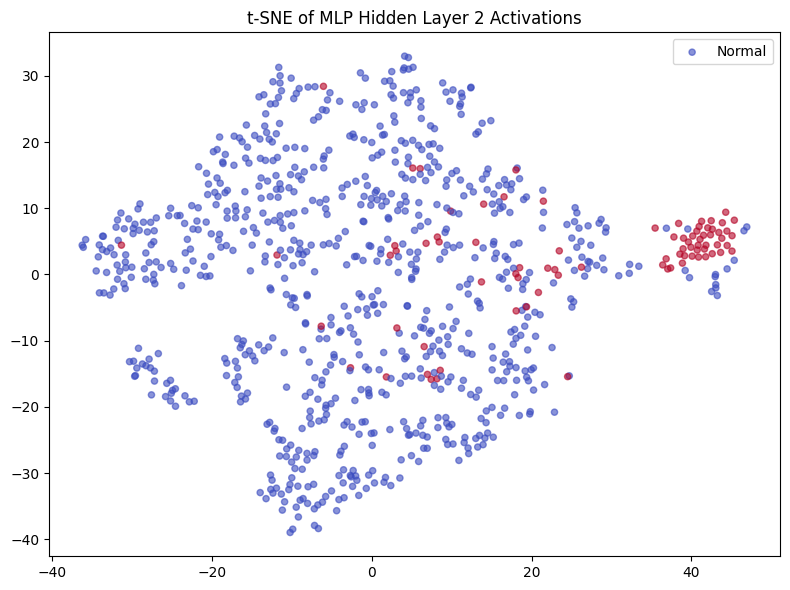

# of predictions: 220


In [16]:
# Tunable paramters:
from sklearn.utils import compute_sample_weight


val_split = 0.15
initial_learning_rate = 0.001
ridge_alpha = 0.1
ridge_alpha_smote = 10

mlp_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),                  # two hidden layers: 64 neurons then 32
        activation="relu",                            # standard activation function
        max_iter=500,                                 # training epochs
        early_stopping=True,                          # stop if validation score stops improving
        validation_fraction=val_split,                # use val_split% of training data for validation and early stopping
        learning_rate_init=initial_learning_rate,     # starting learning rate
        random_state=RANDOM_SEED,
        alpha=ridge_alpha
    ))
])

# To handle imblanace, oversample anomalous users with SMOTE
mlp_smote_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_SEED, k_neighbors=3)),  # creates synthetic anomalous samples
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        validation_fraction=val_split,
        learning_rate_init=initial_learning_rate,
        random_state=RANDOM_SEED,
        alpha=ridge_alpha_smote
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

mlp_scores = []
mlp_smote_scores = []

for train_idx, val_idx in skf.split(X_features, y_labels):
    X_train, X_val = X_features[train_idx], X_features[val_idx]
    y_train, y_val = y_labels[train_idx], y_labels[val_idx]
    
    fold_weights = compute_sample_weight(class_weight="balanced", y=y_train) # compute weights for this fold
    mlp_pipeline.fit(X_train, y_train, mlp__sample_weight=fold_weights) # pass weights to MLP
    y_prob = mlp_pipeline.predict_proba(X_val)[:, 1]
    mlp_scores.append(roc_auc_score(y_val, y_prob))

    mlp_smote_pipeline.fit(X_train, y_train)
    y_prob_smote = mlp_smote_pipeline.predict_proba(X_val)[:, 1]
    mlp_smote_scores.append(roc_auc_score(y_val, y_prob_smote))


print(f"MLP AUC: {np.mean(mlp_scores):.4f} ± {np.std(mlp_scores):.4f}")
print(f"MLP SMOTE AUC: {np.mean(mlp_smote_scores):.4f} ± {np.std(mlp_smote_scores):.4f}")

# Train MLP and MLP_SMOTE on full training data (880 users, test users excluded)
sample_weights = compute_sample_weight(class_weight="balanced", y=y_labels)
mlp_pipeline.fit(X_features, y_labels, mlp__sample_weight=sample_weights)
mlp_smote_pipeline.fit(X_features, y_labels)

from sklearn.manifold import TSNE

# Extract the scaler and trained MLP
scaler_mlp = mlp_pipeline.named_steps["scaler"]
mlp = mlp_pipeline.named_steps["mlp"]

# Scale the full training set for visualisation
X_scaled = scaler_mlp.transform(X_features)

# Manually pass data through hidden layers to get activations
hidden1 = np.maximum(0, X_scaled @ mlp.coefs_[0] + mlp.intercepts_[0])  # ReLU
hidden2 = np.maximum(0, hidden1 @ mlp.coefs_[1] + mlp.intercepts_[1])   # ReLU

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embeddings = tsne.fit_transform(hidden2)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    embeddings[:, 0], embeddings[:, 1],
    c=y_labels, cmap="coolwarm", alpha=0.6, s=20
)
ax.set_title("t-SNE of MLP Hidden Layer 2 Activations")
ax.legend(*scatter.legend_elements(), labels=["Normal", "Anomalous"])
plt.tight_layout()
plt.show()

# Predict on test set (220 unseen users)
y_score_mlp_v2 = mlp_pipeline.predict_proba(X_test)[:, 1]
y_score_smote_v2 = mlp_smote_pipeline.predict_proba(X_test)[:, 1]

print(f"# of predictions: {len(y_score_mlp_v2)}")

In [25]:
# Local evaluation — test_labels loaded in cell 1 (from yy_all, not leaked yy)
print("MLP v2 (local test set — 220 unseen users):")
print(f"AUC: {roc_auc_score(test_labels, y_score_mlp_v2):.4f}")
print()
print("MLP SMOTE v2 (local test set — 220 unseen users):")
print(f"AUC: {roc_auc_score(test_labels, y_score_smote_v2):.4f}")

# Save as submission.npz
np.savez('mlp_smote_v2.npz', predictions=y_score_smote_v2)

MLP v2 (local test set — 220 unseen users):
AUC: 0.8490

MLP SMOTE v2 (local test set — 220 unseen users):
AUC: 0.8732


### What's new: 
#### Tuned L2 reg alpha for both:
- alpha=0.1 (MLP): weighted L2 → less overfitting, weights stay smaller
- alpha=10 (MLP SMOTE): more regularization to counteract SMOTE's tendency to overfit synthetic samples
- k_neighbors=3: SMOTE interpolates between the 3 nearest anomalous neighbors instead of 5 -> tighter, more realistic synthetic samples
> MLP_SMOTE score incerased to 0.898

### sample weight for none Smote MLP
- Forces the MLP model to care more about getting anomalies right
> MLP peaked at 0.75, minimal improvement compared to smote

> Submitted score 0.90 - **sorry I forgot to get the other score lol**

## **Phase 1: First Batch**